# 📚 Kindle Review Sentiment Analysis using Machine Learning

## 📌 Project Overview

Sentiment Analysis is a Natural Language Processing (NLP) task that aims to identify the sentiment expressed in a piece of text. In this project, we classify Kindle product reviews as **Positive** or **Negative** based on the review content.

The project demonstrates a complete text classification pipeline, including text preprocessing, multiple feature extraction techniques, and the performance comparison of several machine learning algorithms.

---

## 🎯 Objective

The main objectives of this project are:

- Build a sentiment classification model for Kindle reviews.
- Perform text preprocessing using NLP techniques.
- Compare different text representation techniques.
- Evaluate multiple machine learning models.
- Identify the best-performing feature extraction and classification combination.

---

## 🛠️ Workflow

```
Load Dataset
      │
      ▼
Basic Data Analysis
      │
      ▼
Text Preprocessing
      │
      ▼
Feature Extraction
(BoW • TF-IDF • Average Word2Vec)
      │
      ▼
Machine Learning Models
(Logistic Regression • Linear SVM • Random Forest • XGBoost)
      │
      ▼
Model Evaluation
      │
      ▼
Best Model Selection
```

In [1]:
# ==========================================================
# Import Required Libraries
# ==========================================================

# Regular Expression
import re

# Numerical Computing
import numpy as np

# Data Manipulation
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Natural Language Processing
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Word Embedding
from gensim.models import Word2Vec

# Feature Extraction
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Data Splitting
from sklearn.model_selection import train_test_split

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# ==========================================================
# Download Required NLTK Resources
# ==========================================================

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/milind/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/milind/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/milind/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [3]:
# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_csv("all_kindle_review.csv")

df.head()

,Unnamed: 0.1,Unnamed: 0,asin,helpful,rating,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime
0,0,11539,B0033UV8HI,"[8, 10]",3,"Jace Rankin may be short, but he's nothing to ...","09 2, 2010",A3HHXRELK8BHQG,Ridley,Entertaining But Average,1283385600
1,1,5957,B002HJV4DE,"[1, 1]",5,Great short read. I didn't want to put it dow...,"10 8, 2013",A2RGNZ0TRF578I,Holly Butler,Terrific menage scenes!,1381190400
2,2,9146,B002ZG96I4,"[0, 0]",3,I'll start by saying this is the first of four...,"04 11, 2014",A3S0H2HV6U1I7F,Merissa,Snapdragon Alley,1397174400
3,3,7038,B002QHWOEU,"[1, 3]",3,Aggie is Angela Lansbury who carries pocketboo...,"07 5, 2014",AC4OQW3GZ919J,Cleargrace,very light murder cozy,1404518400
4,4,1776,B001A06VJ8,"[0, 1]",4,I did not expect this type of book to be in li...,"12 31, 2012",A3C9V987IQHOQD,Rjostler,Book,1356912000


In [4]:
# ==========================================================
# Dataset Information
# ==========================================================

print("=" * 60)
print("Dataset Shape")
print("=" * 60)

print(df.shape)

print("\nColumns")
print(df.columns.tolist())

Dataset Shape
(12000, 11)

Columns
['Unnamed: 0.1', 'Unnamed: 0', 'asin', 'helpful', 'rating', 'reviewText', 'reviewTime', 'reviewerID', 'reviewerName', 'summary', 'unixReviewTime']


In [5]:
# ==========================================================
# Display Random Reviews
# ==========================================================

df.sample(5, random_state=42)

,Unnamed: 0.1,Unnamed: 0,asin,helpful,rating,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime
1935,1935,14172,B003AKY45Y,"[0, 0]",3,Was a really great read just wish there would ...,"06 8, 2013",A2UG2DKXE0XHSL,Carollann,Really enjoyed this book.,1370649600
6494,6494,26105,B0041846M0,"[0, 0]",1,Nope. I tried. Can't read it. I will take the ...,"07 3, 2013",A3LXAMETKF2MZ0,Andrew Bauld,yuck,1372809600
1720,1720,11888,B00359FHZ6,"[0, 0]",2,The story line just drug on and on. I did not ...,"06 28, 2014",AHKATP7LPRPIJ,Cathy J. Malone,Way too Long,1403913600
9120,9120,25040,B00408AQ98,"[9, 13]",1,I have read several angel books but this one d...,"01 4, 2011",A3IOJ6U63ZT67K,Jennifer Maskaly,Flat characters and too many sex scenes!,1294099200
360,360,13950,B0039NMTFO,"[5, 6]",1,Possibly the worst book I have ever read. The...,"07 11, 2012",A3AOR3Q8769B2N,Tech Geek,Was this written by a 13 year old?,1341964800


## 📊 Exploratory Data Analysis (EDA)

Before building the sentiment analysis model, we perform a brief exploration of the dataset to understand its structure and data quality.

In this section, we will:

- Inspect the dataset dimensions
- Check data types
- Identify missing values
- Remove unnecessary columns
- Create sentiment labels from ratings
- Visualize the sentiment distribution

## 1️⃣ Dataset Information

In [6]:
# ==========================================================
# Dataset Information
# ==========================================================

print("=" * 60)
print("Dataset Information")
print("=" * 60)

df.info()

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Unnamed: 0.1    12000 non-null  int64
 1   Unnamed: 0      12000 non-null  int64
 2   asin            12000 non-null  str  
 3   helpful         12000 non-null  str  
 4   rating          12000 non-null  int64
 5   reviewText      12000 non-null  str  
 6   reviewTime      12000 non-null  str  
 7   reviewerID      12000 non-null  str  
 8   reviewerName    11962 non-null  str  
 9   summary         11998 non-null  str  
 10  unixReviewTime  12000 non-null  int64
dtypes: int64(4), str(7)
memory usage: 8.8 MB


## 2️⃣ Missing Values

In [7]:
# ==========================================================
# Missing Values
# ==========================================================

print("=" * 60)
print("Missing Values")
print("=" * 60)

df.isnull().sum()

Missing Values


Unnamed: 0.1       0
Unnamed: 0         0
asin               0
helpful            0
rating             0
reviewText         0
reviewTime         0
reviewerID         0
reviewerName      38
summary            2
unixReviewTime     0
dtype: int64

## 3️⃣ Select Required Columns

Your dataset has 11 columns, but for sentiment analysis we only need:

* reviewText
* rating

Everything else (reviewerID, summary, asin, etc.) isn’t needed for this notebook.

In [8]:
# ==========================================================
# Select Required Columns
# ==========================================================

df = df[["reviewText", "rating"]]

df.head()

,reviewText,rating
0,"Jace Rankin may be short, but he's nothing to ...",3
1,Great short read. I didn't want to put it dow...,5
2,I'll start by saying this is the first of four...,3
3,Aggie is Angela Lansbury who carries pocketboo...,3
4,I did not expect this type of book to be in li...,4


## 4️⃣ Dataset Shape After Column Selection

In [9]:
# ==========================================================
# Dataset Shape
# ==========================================================

print("=" * 60)
print("Dataset Shape")
print("=" * 60)

print(df.shape)

Dataset Shape
(12000, 2)


## 5️⃣ Check Missing Values Again

In [10]:
# ==========================================================
# Missing Values
# ==========================================================

df.isnull().sum()

reviewText    0
rating        0
dtype: int64

## 6️⃣ Remove Missing Reviews

In [11]:
# ==========================================================
# Remove Missing Reviews
# ==========================================================

df.dropna(inplace=True)

df.reset_index(drop=True, inplace=True)

df.shape

(12000, 2)

## 7️⃣ Rating Distribution

In [12]:
# ==========================================================
# Rating Distribution
# ==========================================================

df["rating"].value_counts().sort_index()

rating
1    2000
2    2000
3    2000
4    3000
5    3000
Name: count, dtype: int64

## 8️⃣ Visualize Rating Distribution

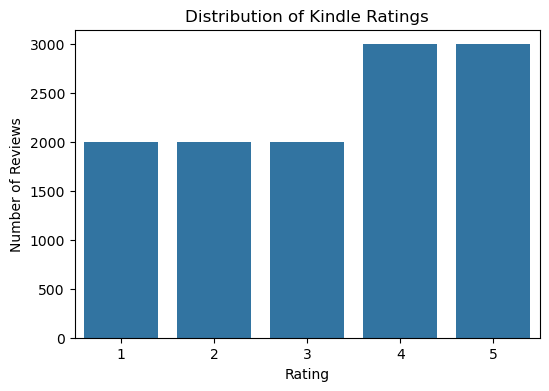

In [13]:
# ==========================================================
# Rating Distribution
# ==========================================================

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="rating"
)

plt.title("Distribution of Kindle Ratings")

plt.xlabel("Rating")

plt.ylabel("Number of Reviews")

plt.show()

## 9️⃣ Create Sentiment Labels

Most Kindle review datasets follow this mapping:

* Rating ≥ 3 → Positive (1)
* Rating < 3 → Negative (0)

This also matches the approach used in your original notebook.

In [14]:
# ==========================================================
# Create Sentiment Labels
# ==========================================================

df["sentiment"] = df["rating"].apply(

    lambda rating: 1 if rating >= 3 else 0

)

df.head()

,reviewText,rating,sentiment
0,"Jace Rankin may be short, but he's nothing to ...",3,1
1,Great short read. I didn't want to put it dow...,5,1
2,I'll start by saying this is the first of four...,3,1
3,Aggie is Angela Lansbury who carries pocketboo...,3,1
4,I did not expect this type of book to be in li...,4,1


## 🔟 Sentiment Distribution

In [15]:
# ==========================================================
# Sentiment Distribution
# ==========================================================

df["sentiment"].value_counts()

sentiment
1    8000
0    4000
Name: count, dtype: int64

## 1️⃣1️⃣ Visualize Sentiment Distribution

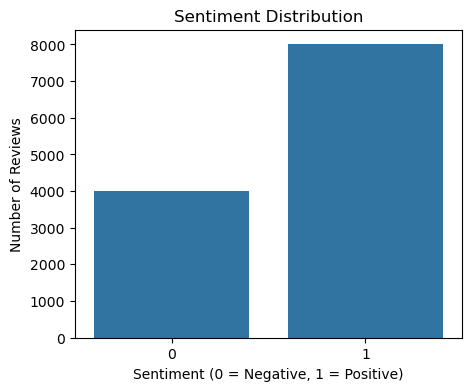

In [16]:
# ==========================================================
# Sentiment Distribution
# ==========================================================

plt.figure(figsize=(5,4))

sns.countplot(
    data=df,
    x="sentiment"
)

plt.title("Sentiment Distribution")

plt.xlabel("Sentiment (0 = Negative, 1 = Positive)")

plt.ylabel("Number of Reviews")

plt.show()

## 📝 Step 3: Text Preprocessing

## 🧹 Text Preprocessing

Raw text often contains punctuation, special characters, HTML tags, numbers, and common words that do not contribute significantly to sentiment prediction.

To prepare the reviews for machine learning models, we perform the following preprocessing steps:

- Convert text to lowercase
- Remove HTML tags
- Remove special characters and numbers
- Tokenize text
- Remove stopwords
- Apply WordNet Lemmatization

The cleaned text is then used for feature extraction techniques such as Bag of Words (BoW), TF-IDF, and Average Word2Vec.

## 1️⃣ Initialize NLP Objects

In [17]:
# ==========================================================
# Initialize NLP Objects
# ==========================================================

stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

## 2️⃣ Create Preprocessing Function

In [18]:
# ==========================================================
# Text Preprocessing Function
# ==========================================================

def preprocess_text(text):
    """
    Perform text preprocessing on a review.

    Steps:
    1. Convert text to lowercase
    2. Remove HTML tags
    3. Remove special characters and numbers
    4. Tokenize text
    5. Remove stopwords
    6. Apply WordNet Lemmatization

    Parameters
    ----------
    text : str
        Input review text.

    Returns
    -------
    str
        Cleaned review.
    """

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Keep only alphabetic characters
    text = re.sub(r"[^a-zA-Z]", " ", text)

    # Tokenize
    words = text.split()

    # Remove stopwords and apply lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    # Join words into a sentence
    return " ".join(words)

## 3️⃣ Apply Text Preprocessing

In [19]:
# ==========================================================
# Apply Text Preprocessing
# ==========================================================

df["clean_review"] = df["reviewText"].apply(preprocess_text)

df.head()

,reviewText,rating,sentiment,clean_review
0,"Jace Rankin may be short, but he's nothing to ...",3,1,jace rankin may short nothing mess man hauled ...
1,Great short read. I didn't want to put it dow...,5,1,great short read want put read one sitting sex...
2,I'll start by saying this is the first of four...,3,1,start saying first four book expecting conclud...
3,Aggie is Angela Lansbury who carries pocketboo...,3,1,aggie angela lansbury carry pocketbook instead...
4,I did not expect this type of book to be in li...,4,1,expect type book library pleased find price right


## 4️⃣ Compare Original and Processed Reviews

In [20]:
# ==========================================================
# Original vs Processed Reviews
# ==========================================================

for original, cleaned in zip(
    df["reviewText"].head(5),
    df["clean_review"].head(5)
):
    print("=" * 80)
    print("Original Review\n")
    print(original)

    print("\nProcessed Review\n")
    print(cleaned)

    print()

Original Review

Jace Rankin may be short, but he's nothing to mess with, as the man who was just hauled out of the saloon by the undertaker knows now. He's a famous bounty hunter in Oregon in the 1890s who, when he shot the man in the saloon, just finished a years long quest to avenge his sister's murder and is now trying to figure out what to do next. When the snotty-nosed farm boy he just rescued from a gang of bullies offers him money to kill a man who forced him off his ranch, he reluctantly agrees to bring the man to justice, but not to kill him outright. But, first he needs to tell his sister's widower the news.Kyla "Kyle" Springer Bailey has been riding the trails and sleeping on the ground for the past month while trying to find Jace. She wants revenge on the man who killed her husband and took her ranch, amongst other crimes, and she's not so keen on the detour Jace wants to take. But she realizes she's out of options, so she hides behind her boy persona as best she can and t

## 5️⃣ Remove Empty Reviews

Some reviews may become empty after preprocessing (for example, reviews containing only punctuation, numbers, or emojis).

In [21]:
# ==========================================================
# Remove Empty Reviews
# ==========================================================

df = df[df["clean_review"].str.len() > 0]

df.reset_index(drop=True, inplace=True)

print(df.shape)

(12000, 4)


## 6️⃣ Check Empty Reviews (Debugging)

This cell isn’t mandatory, but it’s useful to verify which reviews became empty after cleaning.

In [22]:
# ==========================================================
# Empty Reviews After Preprocessing
# ==========================================================

empty_reviews = [
    [len(review), review, original]
    for review, original in zip(
        df["clean_review"],
        df["reviewText"]
    )
    if len(review) == 0
]

empty_reviews

[]

## 📌 Step 4: Train-Test Split

## ✂️ Train-Test Split

Before converting the reviews into numerical features, the dataset is divided into training and testing sets.

- **Training Set (80%)** is used to train the machine learning models.
- **Testing Set (20%)** is used to evaluate the performance of the trained models on unseen data.

Using the same train-test split for all feature extraction techniques ensures a fair comparison between different models.

## 1️⃣ Define Features and Target

In [23]:
# ==========================================================
# Define Features and Target
# ==========================================================

X = df["clean_review"]

y = df["sentiment"]

## 2️⃣ Train-Test Split

In [24]:
# ==========================================================
# Train-Test Split
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

Why stratify=y?

Since this is a binary sentiment classification problem, stratify=y ensures that the proportion of positive and negative reviews remains similar in both the training and testing sets.

In [25]:
# ==========================================================
# Training and Testing Dataset Size
# ==========================================================

print("=" * 60)
print("Training Dataset")
print("=" * 60)

print(X_train.shape)
print(y_train.shape)

print()

print("=" * 60)
print("Testing Dataset")
print("=" * 60)

print(X_test.shape)
print(y_test.shape)

Training Dataset
(9600,)
(9600,)

Testing Dataset
(2400,)
(2400,)


## 4️⃣ Verify Sentiment Distribution

This is a small but professional check to ensure the split preserved the class distribution.

In [26]:
# ==========================================================
# Sentiment Distribution
# ==========================================================

print("=" * 60)
print("Training Set")
print("=" * 60)

print(y_train.value_counts(normalize=True).round(3))

print()

print("=" * 60)
print("Testing Set")
print("=" * 60)

print(y_test.value_counts(normalize=True).round(3))

Training Set
sentiment
1    0.667
0    0.333
Name: proportion, dtype: float64

Testing Set
sentiment
1    0.667
0    0.333
Name: proportion, dtype: float64


X_train  → Clean Review Text
X_test   → Clean Review Text

y_train  → Sentiment Labels
y_test   → Sentiment Labels

## ✅ End of Step 4

At this stage, we’ll have:

X_train  → Clean Review Text
X_test   → Clean Review Text

y_train  → Sentiment Labels
y_test   → Sentiment Labels

## 📝 Step 5A: Bag of Words (BoW)

## 🔤 Bag of Words (BoW)

Bag of Words (BoW) is one of the simplest and most widely used text representation techniques. It converts each review into a numerical vector based on the frequency of words appearing in the training dataset.

Although BoW ignores word order and semantic relationships, it serves as a strong baseline for many text classification tasks.

## 1️⃣ Create BoW Features

In [27]:
# ==========================================================
# Bag of Words (BoW)
# ==========================================================

bow_vectorizer = CountVectorizer()

X_train_bow = bow_vectorizer.fit_transform(X_train)

X_test_bow = bow_vectorizer.transform(X_test)

## 2️⃣ Feature Matrix Information

In [28]:
# ==========================================================
# BoW Feature Matrix
# ==========================================================

print("=" * 60)
print("Bag of Words Feature Matrix")
print("=" * 60)

print(f"Training Shape : {X_train_bow.shape}")

print(f"Testing Shape  : {X_test_bow.shape}")

print(f"Vocabulary Size: {len(bow_vectorizer.vocabulary_)}")

Bag of Words Feature Matrix
Training Shape : (9600, 23860)
Testing Shape  : (2400, 23860)
Vocabulary Size: 23860


## 📝 Step 5B: TF-IDF
## 📊 TF-IDF (Term Frequency–Inverse Document Frequency)

TF-IDF is an extension of Bag of Words that assigns higher importance to informative words while reducing the influence of frequently occurring words.

Compared to BoW, TF-IDF often produces better representations for text classification problems because it captures the relative importance of each word across the entire dataset.

## 1️⃣ Create TF-IDF Features

In [29]:
# ==========================================================
# TF-IDF
# ==========================================================

tfidf_vectorizer = TfidfVectorizer()

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

X_test_tfidf = tfidf_vectorizer.transform(X_test)

## 2️⃣ Feature Matrix Information

In [30]:
# ==========================================================
# TF-IDF Feature Matrix
# ==========================================================

print("=" * 60)
print("TF-IDF Feature Matrix")
print("=" * 60)

print(f"Training Shape : {X_train_tfidf.shape}")

print(f"Testing Shape  : {X_test_tfidf.shape}")

print(f"Vocabulary Size: {len(tfidf_vectorizer.vocabulary_)}")

TF-IDF Feature Matrix
Training Shape : (9600, 23860)
Testing Shape  : (2400, 23860)
Vocabulary Size: 23860


## 📝 Step 5C: Average Word2Vec

Unlike the Spam notebook, we’ll not spend time inspecting vectors, similar words, or vocabulary. We’ll directly build the embeddings needed for classification.

## 🌐 Average Word2Vec

Word2Vec learns dense vector representations of words by capturing their semantic relationships from the training corpus.

Since machine learning models require a fixed-length input, each review is represented by the average of all its word vectors, producing a single numerical vector for every review.

## 1️⃣ Prepare Tokenized Reviews

Word2Vec expects a list of tokens, not a sentence.

In [31]:
# ==========================================================
# Tokenize Reviews
# ==========================================================

X_train_tokens = X_train.apply(lambda review: review.split())

X_test_tokens = X_test.apply(lambda review: review.split())

## 2️⃣ Train Word2Vec Model

In [32]:
# ==========================================================
# Train Word2Vec Model
# ==========================================================

word2vec_model = Word2Vec(

    sentences=X_train_tokens,

    vector_size=100,

    window=5,

    min_count=2,

    workers=4,

    sg=1,

    seed=42
)

print("Word2Vec Model Trained Successfully!")

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Word2Vec Model Trained Successfully!


## 3️⃣ Create Average Word2Vec Function

In [33]:
# ==========================================================
# Average Word2Vec Function
# ==========================================================

def average_word2vec(words, model, vector_size):
    """
    Convert a tokenized review into a fixed-length
    Average Word2Vec feature vector.
    """

    feature_vector = np.zeros(vector_size, dtype="float32")

    word_count = 0

    for word in words:

        if word in model.wv:

            feature_vector += model.wv[word]

            word_count += 1

    if word_count > 0:

        feature_vector /= word_count

    return feature_vector

## 4️⃣ Generate Training Features

In [34]:
# ==========================================================
# Average Word2Vec Features (Training)
# ==========================================================

X_train_w2v = np.array([

    average_word2vec(

        review,

        word2vec_model,

        100

    )

    for review in X_train_tokens

])

print(X_train_w2v.shape)

(9600, 100)


## 5️⃣ Generate Testing Features

In [35]:
# ==========================================================
# Average Word2Vec Features (Testing)
# ==========================================================

X_test_w2v = np.array([

    average_word2vec(

        review,

        word2vec_model,

        100

    )

    for review in X_test_tokens

])

print(X_test_w2v.shape)

(2400, 100)


## 6️⃣ Verify Feature Matrix

In [36]:
# ==========================================================
# Average Word2Vec Feature Matrix
# ==========================================================

print("=" * 60)
print("Average Word2Vec Feature Matrix")
print("=" * 60)

print(f"Training Shape : {X_train_w2v.shape}")

print(f"Testing Shape  : {X_test_w2v.shape}")

print(f"Embedding Size : {X_train_w2v.shape[1]}")

Average Word2Vec Feature Matrix
Training Shape : (9600, 100)
Testing Shape  : (2400, 100)
Embedding Size : 100


## 📚 Step 6: Model Building & Evaluation
## 🤖 Model Training and Evaluation

To evaluate the effectiveness of different text representations, multiple machine learning models are trained on each feature extraction technique.

The following classifiers are used:

- Logistic Regression
- Linear Support Vector Machine (Linear SVM)
- Random Forest
- XGBoost

Each model is evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score

Finally, the performance of all models is compared to identify the best combination of feature extraction technique and classifier.

## 1️⃣ Define Models

In [37]:
# ==========================================================
# Machine Learning Models
# ==========================================================

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Linear SVM": LinearSVC(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        eval_metric="logloss"
    )
}

## Step 2: Create Feature Dictionary

In [38]:
feature_info = {
    "Bag of Words": X_train_bow.shape[1],
    "TF-IDF": X_train_tfidf.shape[1],
    "Average Word2Vec": X_train_w2v.shape[1]
}

## 2️⃣ Create Evaluation Function

In [39]:
# ==========================================================
# Model Evaluation Function
# ==========================================================
import time

# ==========================================================
# Model Evaluation Function
# ==========================================================

def evaluate_models(
    X_train,
    X_test,
    y_train,
    y_test,
    feature_name
):

    results = []

    for model_name, model in models.items():

        # -----------------------------
        # Training
        # -----------------------------
        start_train = time.perf_counter()

        model.fit(X_train, y_train)

        train_time = time.perf_counter() - start_train

        # -----------------------------
        # Prediction
        # -----------------------------
        start_predict = time.perf_counter()

        y_pred = model.predict(X_test)

        predict_time = time.perf_counter() - start_predict

        # -----------------------------
        # ROC-AUC
        # -----------------------------
        if hasattr(model, "predict_proba"):

            y_score = model.predict_proba(X_test)[:, 1]

        elif hasattr(model, "decision_function"):

            y_score = model.decision_function(X_test)

        else:

            y_score = y_pred

        # -----------------------------
        # Store Results
        # -----------------------------
        results.append({

                "Feature Extraction": feature_name,
            
                "Model": model_name,
            
                "Estimator": model,
            
                "Accuracy": accuracy_score(y_test, y_pred),
            
                "Precision": precision_score(y_test, y_pred),
            
                "Recall": recall_score(y_test, y_pred),
            
                "F1-Score": f1_score(y_test, y_pred),
            
                "ROC-AUC": roc_auc_score(y_test, y_score),
            
                "Training Time (s)": train_time,
            
                "Prediction Time (ms)": predict_time * 1000,
            
                "Features": feature_info[feature_name]
            
})

    return pd.DataFrame(results)

## 3️⃣ Evaluate Bag of Words

In [40]:
bow_results = evaluate_models(

    X_train_bow,
    X_test_bow,

    y_train,
    y_test,

    "Bag of Words"

)

## 4️⃣ Evaluate TF-IDF

In [41]:
tfidf_results = evaluate_models(

    X_train_tfidf,
    X_test_tfidf,

    y_train,
    y_test,

    "TF-IDF"

)

## 5️⃣ Evaluate Average Word2Vec

In [42]:
word2vec_results = evaluate_models(

    X_train_w2v,
    X_test_w2v,

    y_train,
    y_test,

    "Average Word2Vec"

)

## 6️⃣ Combine Results

In [43]:
comparison = pd.concat(

    [

        bow_results,

        tfidf_results,

        word2vec_results

    ],

    ignore_index=True

)

## 7️⃣ Display Results

In [44]:
comparison = pd.concat(

    [
        bow_results,
        tfidf_results,
        word2vec_results
    ],

    ignore_index=True

)

comparison = comparison.round({

    "Accuracy":4,
    "Precision":4,
    "Recall":4,
    "F1-Score":4,
    "ROC-AUC":4,
    "Training Time (s)":4,
    "Prediction Time (ms)":2

})

comparison.sort_values(
    by="Accuracy",
    ascending=False,
    inplace=True
)

comparison.reset_index(drop=True, inplace=True)

comparison

,Feature Extraction,Model,Estimator,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Training Time (s),Prediction Time (ms),Features
0,TF-IDF,Logistic Regression,"LogisticRegression(max_iter=1000, random_state...",0.8508,0.8493,0.9438,0.8940,0.9266,0.1878,0.39,23860
1,TF-IDF,Linear SVM,LinearSVC(random_state=42),0.8471,0.8694,0.9069,0.8877,0.9129,0.0332,0.21,23860
2,Bag of Words,Logistic Regression,"LogisticRegression(max_iter=1000, random_state...",0.8421,0.8654,0.9038,0.8841,0.8964,0.2951,0.25,23860
3,Average Word2Vec,Linear SVM,LinearSVC(random_state=42),0.8350,0.8508,0.9125,0.8806,0.9022,0.1351,0.28,100
4,TF-IDF,XGBoost,"XGBClassifier(base_score=None, booster=None, c...",0.8258,0.8305,0.9281,0.8766,0.8896,5.0538,5.83,23860
5,Average Word2Vec,Logistic Regression,"LogisticRegression(max_iter=1000, random_state...",0.8258,0.8400,0.9125,0.8748,0.8964,0.0282,0.27,100
6,Average Word2Vec,XGBoost,"XGBClassifier(base_score=None, booster=None, c...",0.8238,0.8501,0.8931,0.8711,0.8941,0.7380,1.22,100
7,Bag of Words,XGBoost,"XGBClassifier(base_score=None, booster=None, c...",0.8146,0.8224,0.9206,0.8688,0.8858,0.9453,6.42,23860
8,Average Word2Vec,Random Forest,"(DecisionTreeClassifier(max_features='sqrt', r...",0.8129,0.8294,0.9056,0.8659,0.8829,1.1302,26.46,100
9,Bag of Words,Linear SVM,LinearSVC(random_state=42),0.8071,0.8511,0.8612,0.8562,0.8553,0.3104,0.27,23860


## 8️⃣ Sort Results

In [45]:
comparison = comparison.sort_values(

    by="Accuracy",

    ascending=False

).reset_index(drop=True)

comparison

,Feature Extraction,Model,Estimator,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Training Time (s),Prediction Time (ms),Features
0,TF-IDF,Logistic Regression,"LogisticRegression(max_iter=1000, random_state...",0.8508,0.8493,0.9438,0.8940,0.9266,0.1878,0.39,23860
1,TF-IDF,Linear SVM,LinearSVC(random_state=42),0.8471,0.8694,0.9069,0.8877,0.9129,0.0332,0.21,23860
2,Bag of Words,Logistic Regression,"LogisticRegression(max_iter=1000, random_state...",0.8421,0.8654,0.9038,0.8841,0.8964,0.2951,0.25,23860
3,Average Word2Vec,Linear SVM,LinearSVC(random_state=42),0.8350,0.8508,0.9125,0.8806,0.9022,0.1351,0.28,100
4,TF-IDF,XGBoost,"XGBClassifier(base_score=None, booster=None, c...",0.8258,0.8305,0.9281,0.8766,0.8896,5.0538,5.83,23860
5,Average Word2Vec,Logistic Regression,"LogisticRegression(max_iter=1000, random_state...",0.8258,0.8400,0.9125,0.8748,0.8964,0.0282,0.27,100
6,Average Word2Vec,XGBoost,"XGBClassifier(base_score=None, booster=None, c...",0.8238,0.8501,0.8931,0.8711,0.8941,0.7380,1.22,100
7,Bag of Words,XGBoost,"XGBClassifier(base_score=None, booster=None, c...",0.8146,0.8224,0.9206,0.8688,0.8858,0.9453,6.42,23860
8,Average Word2Vec,Random Forest,"(DecisionTreeClassifier(max_features='sqrt', r...",0.8129,0.8294,0.9056,0.8659,0.8829,1.1302,26.46,100
9,Bag of Words,Linear SVM,LinearSVC(random_state=42),0.8071,0.8511,0.8612,0.8562,0.8553,0.3104,0.27,23860


## 9️⃣ Best Model

In [46]:
best_model = comparison.iloc[0]

print("=" * 70)

print("🏆 BEST MODEL")

print("=" * 70)

for key, value in best_model.items():

    print(f"{key:<22}: {value}")

🏆 BEST MODEL
Feature Extraction    : TF-IDF
Model                 : Logistic Regression
Estimator             : LogisticRegression(max_iter=1000, random_state=42)
Accuracy              : 0.8508
Precision             : 0.8493
Recall                : 0.9438
F1-Score              : 0.894
ROC-AUC               : 0.9266
Training Time (s)     : 0.1878
Prediction Time (ms)  : 0.39
Features              : 23860


In [47]:
best = comparison.iloc[0]

best_feature = best["Feature Extraction"]
best_model_name = best["Model"]

print(best_feature)
print(best_model_name)

TF-IDF
Logistic Regression


In [48]:
feature_train = {
    "Bag of Words": X_train_bow,
    "TF-IDF": X_train_tfidf,
    "Average Word2Vec": X_train_w2v
}

feature_test = {
    "Bag of Words": X_test_bow,
    "TF-IDF": X_test_tfidf,
    "Average Word2Vec": X_test_w2v
}

In [49]:
from sklearn.base import clone
best_model = clone(models[best_model_name])

best_model.fit(
    feature_train[best_feature],
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [50]:
if hasattr(best_model, "predict_proba"):

    y_score = best_model.predict_proba(
        feature_test[best_feature]
    )[:, 1]

else:

    y_score = best_model.decision_function(
        feature_test[best_feature]
    )

fpr, tpr, _ = roc_curve(y_test, y_score)

auc_score = roc_auc_score(y_test, y_score)

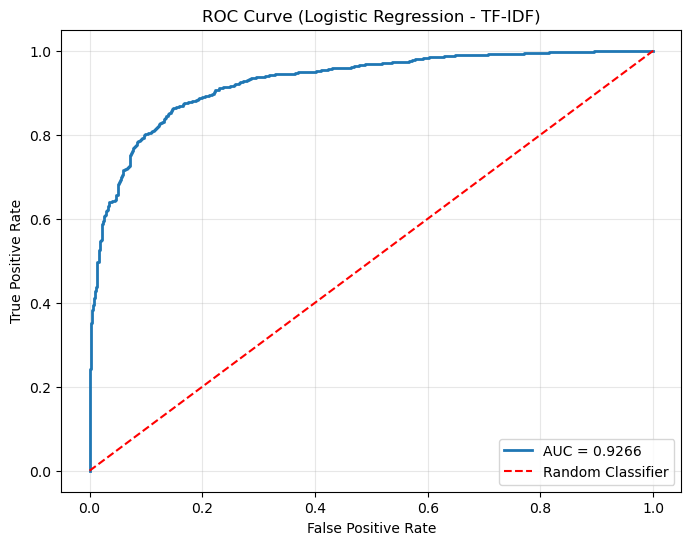

In [51]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {auc_score:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="red",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve ({best_model_name} - {best_feature})")

plt.legend()

plt.grid(alpha=0.3)

plt.show()